In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

from experiment_class import Experiment
from bouts_extension import *
from Reward_Training_Competition.Reward_Competition.rc_extension import Reward_Competition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions


In [2]:
# all data
experiment_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data"
csv_base_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data"

manual_scoring_csv = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\manual_scoring_combined.xlsx"
nac = "#15616F"
mpfc = "#FFAF00"

In [3]:
experiment = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=csv_base_path)

Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data\n1-240611-091131\Notes.txt
read from t=0s to t=2042.14s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data\n1-240612-113256\Notes.txt
read from t=0s to t=2055.01s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data\n1-240614-073020\Notes.txt
read from t=0s to t=2054.68s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data\n2-240611-074031\Notes.txt
read from t=0s to t=2045.31s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data\n2-240612-072325\Notes.txt
read from t=0s to t=2041.48s
Found Synapse note file: C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data\n2-240613-113505\Notes.txt
read from t=0s to t=2047.15

In [4]:
hasattr(experiment, "compute_subject_mean_traces_tone_initiator")

True

In [5]:
experiment.rtc_processing()
experiment.read_and_merge_manual_scoring(manual_scoring_csv)
experiment.remove_specified_subjects()   # Remove specified subjects from the analysis
experiment.remove_tangles()   # Remove sound cues and winner array indexes where there are tangles
experiment.remove_specified_subjects()   # Remove specified subjects from the analysis
experiment.extract_da_columns()   # Grab only essential columns for analysis
experiment.find_first_port_entry_after_sound_cue()
experiment.split_by_winner()

Processing trial n1-240611-091131...
Processing trial n1-240612-113256...
Processing trial n1-240614-073020...
Processing trial n2-240611-074031...
Processing trial n2-240612-072325...
Processing trial n2-240613-113505...
Processing trial n3-240611-115257...
Processing trial n3-240613-085222...
Processing trial n3-240614-090514...
Processing trial n3-240617-095059...
Processing trial n4-240612-085323...
Processing trial n4-240613-072239...
Processing trial n4-240614-130653...
Processing trial n5-240912-080246...
Processing trial n5-240913-094304...
Processing trial n5-240915-060250...
Processing trial n5-240915-095000...
Processing trial n6-240912-062009...
Processing trial n6-240913-062437...
Processing trial n6-240914-065650...
Processing trial n6-240914-095611...
Processing trial n7-240912-095235...
Processing trial n7-240913-080108...
Processing trial n7-240914-082547...
Processing trial n7-240915-073140...
Processing trial nn1-250203-085508...
Processing trial nn3-250203-085508...

In [6]:
# Step 1: Extract and filter Behaviors
bout_definitions = [
    {'prefix': 'subject_behavior', 'behavior': 'Competition Bout', 'subject': 'Subject'},
    {'prefix': 'agent_behavior', 'behavior': 'Competition Bout', 'subject': 'Social Agent'}
]

# Filters for behaviors at/during cue times
experiment.group_extract_manual_annotations2(bout_definitions,first_only=False, pre_window=2.5, cue=True)

C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n5-240912-080246.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n5-240913-094304.csv
After combining # bouts: 2
2
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n5-240915-060250.csv
After combining # bouts: 4
4
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n5-240915-095000.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n7-240912-095235.csv
After combining # bouts: 2
2
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n7-240913-080108.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\n7-240914-082547.csv
After combining # bouts: 1
1
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonre

c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarn

C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\nn4-250203-121223.csv
After combining # bouts: 1
1
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp4-250203-121223.csv
After combining # bouts: 2
2
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\nn5-250205-104235.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\nn8-250205-104235.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\nn5-250203-080636.csv
After combining # bouts: 2
2
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp5-250203-080636.csv
After combining # bouts: 1
0
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\nn6-250203-112333.csv
After combining # bouts: 3
3
C:\Users\yezon\Padilla-Coreano_Lab\Albert_C

c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarn

C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p2-240611-065329.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p2-240612-063828.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p2-240613-104938.csv
After combining # bouts: 2
2
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p3-240613-080730.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p3-240614-081850.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p5-240912-071257.csv
After combining # bouts: 2
2
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p5-240913-085922.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\p5-240915-064653.csv
After combining # bout

c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarn

C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp6-250204-075106.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\nn6-250204-075106.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp6-250203-103606.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp7-250203-103606.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp6-250206-062728.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp7-250206-062728.csv
After combining # bouts: 1
1
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp8-250204-104135.csv
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data\pp5-250204-104135.csv
After combining # bouts: 1
1


c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)
c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\trial_class.py:1352: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.behaviors = pd.concat(self.bouts.values(), ignore_index=True)


In [7]:
# Find associated cues
experiment.find_preceding_cues()
experiment.compute_EI_DA()

Preceding cue mapping complete.


,subject_name,file name,trial,filtered_sound_cues,filtered_port_entries,filtered_port_entry_offset,filtered_winner_array,first_PE_after_sound_cue,Tone_Time_Axis,Tone_Zscore,PE_Time_Axis,PE_Zscore
0,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000024B1E3D4F80>,"[241.12775168, 321.12836608, 411.12895488, 491...","[184.1774592, 185.80733952, 193.31743744, 285....","[184.47745024, 187.45769984, 193.45752064, 285...","[tie, nn8, nn8, nn8, nn8, nn8, nn8, nn8, nn8, ...","[285.35799808, 325.12836608, 415.12895488, 495...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[0.34205379224083243, 0.36543043826706556, 0....","[[0.0, 0.009999999999763531, 0.019999999999527...","[[1.6586763167865775, 1.6031906790993753, 1.53..."
1,pp5,pp5-250203-080636,<trial_class.Trial object at 0x0000024B1E3D7EF0>,"[241.12775168, 321.12836608, 411.12895488, 491...","[181.1275776, 184.02738176, 185.90744576, 187....","[181.68741888, 185.52766464, 186.98747904, 187...","[pp5, pp5, pp5, pp5, pp8, pp5, pp8, pp8, pp8, ...","[245.12775168, 325.12836608, 415.12895488, 495...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.19792605541083613, -0.17205227722198455, ...","[[0.0, 0.009999999999763531, 0.019999999999527...","[[-0.6703055251001239, -0.6769182838597977, -0..."
2,nn1,nn1-250203-085508,<trial_class.Trial object at 0x0000024B1D61F230>,"[250.00820736, 330.00865792, 420.00941056, 500...","[194.11779584, 203.48796928, 215.75778304, 217...","[196.25771008, 206.667776, 217.06801152, 217.8...","[nn2, nn1, nn1, nn1, nn1, nn1, nn2, nn2, nn1, ...","[254.00820736, 334.00865792, 424.00941056, 504...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[0.5508869152942525, 0.552481529789181, 0.554...","[[0.0, 0.009999999999763531, 0.019999999999527...","[[0.4099814608494222, 0.3922095002817799, 0.37..."
3,nn3,nn3-250203-085508,<trial_class.Trial object at 0x0000024B1D575040>,"[250.00820736, 330.00865792, 420.00941056, 500...","[219.1179776, 230.92805632, 231.34830592, 244....","[225.37814016, 231.26818816, 232.78813184, 246...","[nn3, nn4, nn3, nn4, nn4, nn4, nn4, nn4, nn4, ...","[254.00820736, 334.00865792, 424.00941056, 504...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.2407377773517536, -0.2520426177782834, -0...","[[0.0, 0.009999999999763531, 0.019999999999527...","[[1.4901483120867687, 1.4842653480451071, 1.47..."
4,pp1,pp1-250203-094756,<trial_class.Trial object at 0x0000024B1E3D6DE0>,"[240.20205568, 320.20283392, 410.20325888, 490...","[180.20171776, 186.87164416, 194.91192832, 204...","[182.44173824, 189.26174208, 196.0517632, 214....","[pp2, pp2, pp2, pp2, pp1, pp1, pp1, pp1, pp1, ...","[244.20205568, 348.29303808, 414.20325888, 494...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.38764012504863854, -0.37766179110911885, ...","[[0.0, 0.009999999999763531, 0.019999999999527...","[[-0.34699870951127165, -0.3429307291470673, -..."
...,...,...,...,...,...,...,...,...,...,...,...,...
76,p5,p5-240913-085922,<trial_class.Trial object at 0x0000024B1E3D6F90>,"[241.1798528, 321.1804672, 411.18089216, 491.1...","[186.78956032, 187.20964608, 189.38970112, 193...","[187.18949376, 187.71951616, 191.85958912, 194...","[p5, p8, p5, p5, p8, p8, p8, p8, p5, p8, p5, p...","[246.93997568, 325.1804672, 415.18089216, 498....","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[-0.06938485433712094, -0.026226080898226978,...","[[0.0, 0.009999999999763531, 0.019999999999527...","[[-0.7710203734921409, -0.7931648265986899, -0..."
77,p6,p6-240913-054041,<trial_class.Trial object at 0x0000024B1E3D7D10>,"[239.96678144, 319.967232, 409.9678208, 489.96...","[185.55650048, 189.13640448, 192.60653568, 197...","[187.58647808, 189.73638656, 193.11640576, 197...","[p5, p5, p5, p5, p5, p5, p5, p5, p5, p5, p5, p...","[245.51686144, 323.967232, 413.9678208, 493.96...","[[-4.0, -3.9900000000002365, -3.98000000000047...","[[0.25538760391641013, 0.2500584864875439, 0.2...","[[0.0, 0.009999999999763531, 0.019999999999527...","[[-0.6464007700906

In [8]:
experiment.build_event_bank_from_preceding_cues()

19
21
[{'bout_start': 853.8, 'bout_end': 864.3, 'cue_time': np.float64(850.79064576), 'cue_id': np.float64(8.0), 'initiator': 'Subject', 'winner': np.str_('n8')}, {'bout_start': 1596.1, 'bout_end': 1600.4, 'cue_time': np.float64(1595.79488256), 'cue_id': np.float64(16.0), 'initiator': 'Subject', 'winner': np.str_('n5')}]
19
21
[{'bout_start': 493.5, 'bout_end': 511.7, 'cue_time': np.float64(491.89748736), 'cue_id': np.float64(4.0), 'initiator': 'Social Agent', 'winner': np.str_('n5')}, {'bout_start': 1425.5, 'bout_end': 1432.0, 'cue_time': np.float64(1421.90411776), 'cue_id': np.float64(14.0), 'initiator': 'Social Agent', 'winner': np.str_('TIE')}, {'bout_start': 1508.8, 'bout_end': 1510.2, 'cue_time': np.float64(1506.90480128), 'cue_id': np.float64(15.0), 'initiator': 'Social Agent', 'winner': np.str_('n5')}, {'bout_start': 1692.0, 'bout_end': 1705.5, 'cue_time': np.float64(1691.906048), 'cue_id': np.float64(17.0), 'initiator': 'Social Agent', 'winner': np.str_('n5')}]
19
20
[{'bout_s

{'n5-240913-094304': {'Subject': [{'bout_start': 853.8,
    'bout_end': 864.3,
    'cue_time': np.float64(850.79064576),
    'cue_id': np.float64(8.0),
    'initiator': 'Subject',
    'winner': np.str_('n8')},
   {'bout_start': 1596.1,
    'bout_end': 1600.4,
    'cue_time': np.float64(1595.79488256),
    'cue_id': np.float64(16.0),
    'initiator': 'Subject',
    'winner': np.str_('n5')}]},
 'n5-240915-060250': {'Social Agent': [{'bout_start': 493.5,
    'bout_end': 511.7,
    'cue_time': np.float64(491.89748736),
    'cue_id': np.float64(4.0),
    'initiator': 'Social Agent',
    'winner': np.str_('n5')},
   {'bout_start': 1425.5,
    'bout_end': 1432.0,
    'cue_time': np.float64(1421.90411776),
    'cue_id': np.float64(14.0),
    'initiator': 'Social Agent',
    'winner': np.str_('TIE')},
   {'bout_start': 1508.8,
    'bout_end': 1510.2,
    'cue_time': np.float64(1506.90480128),
    'cue_id': np.float64(15.0),
    'initiator': 'Social Agent',
    'winner': np.str_('n5')},
   {'bou

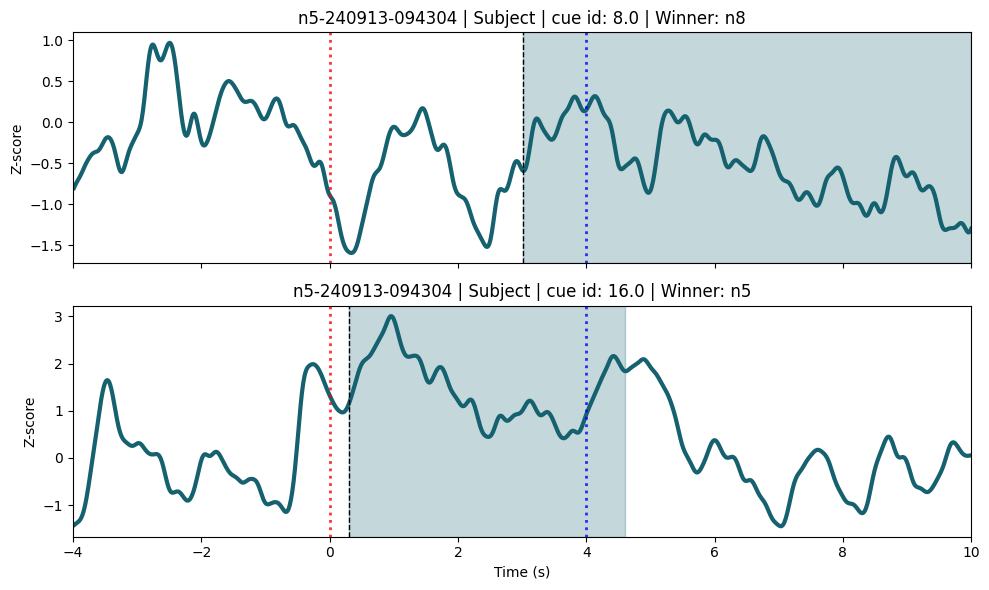

[SKIP] No valid bouts for n5-240915-060250, initiator=Subject


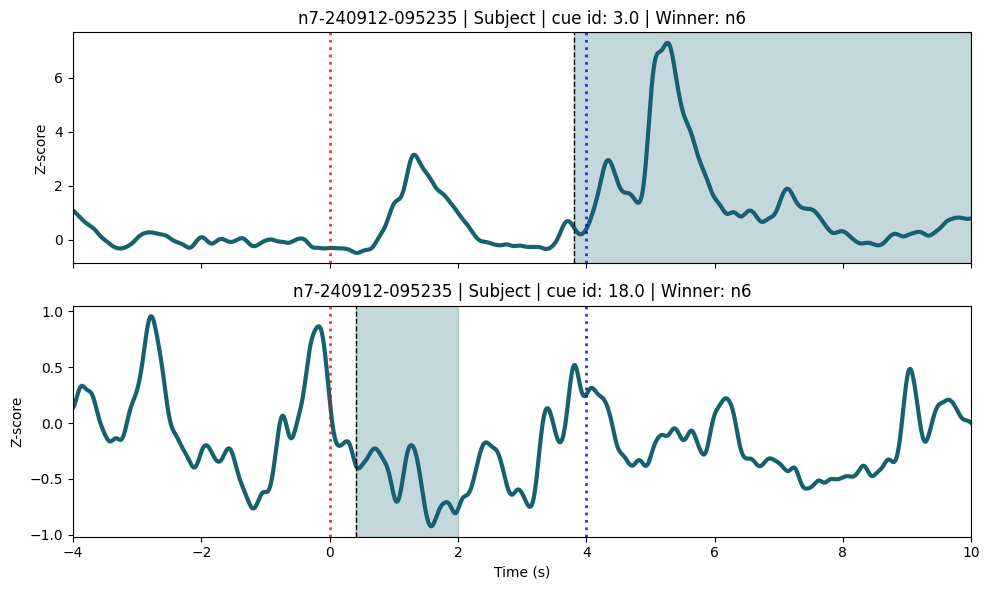

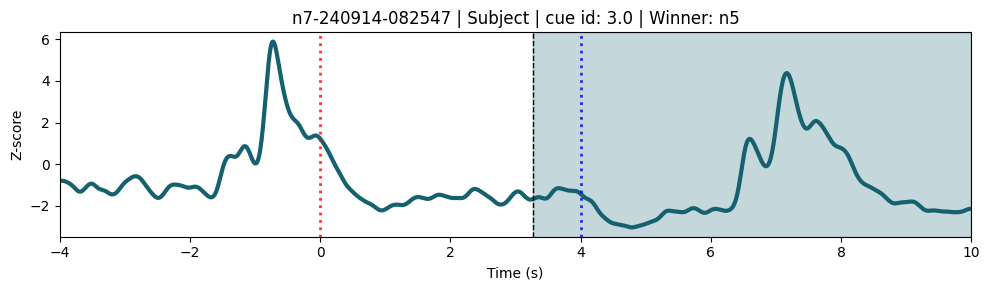

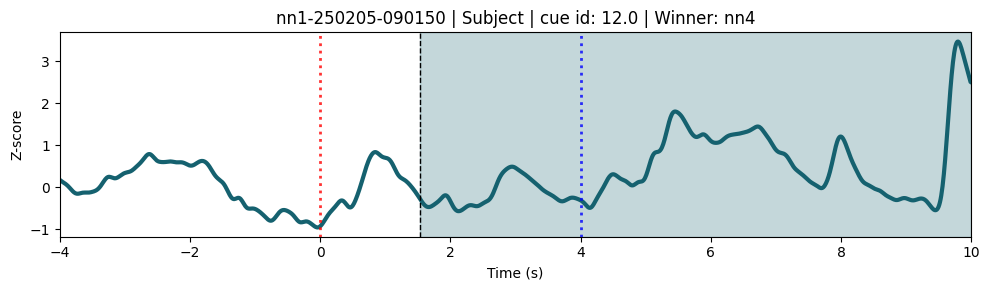

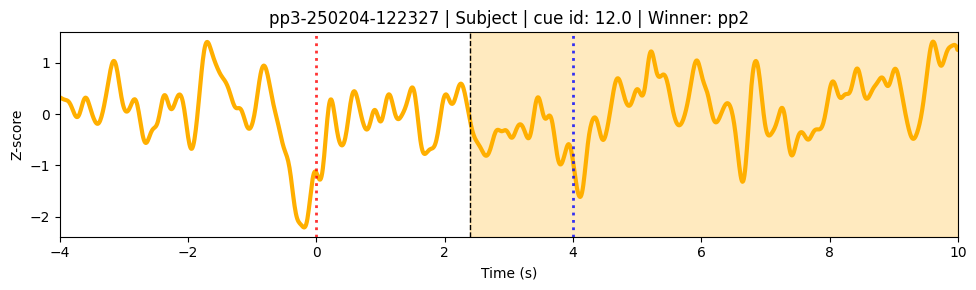

[SKIP] No valid bouts for nn4-250203-121223, initiator=Subject
[SKIP] No valid bouts for pp4-250203-121223, initiator=Subject


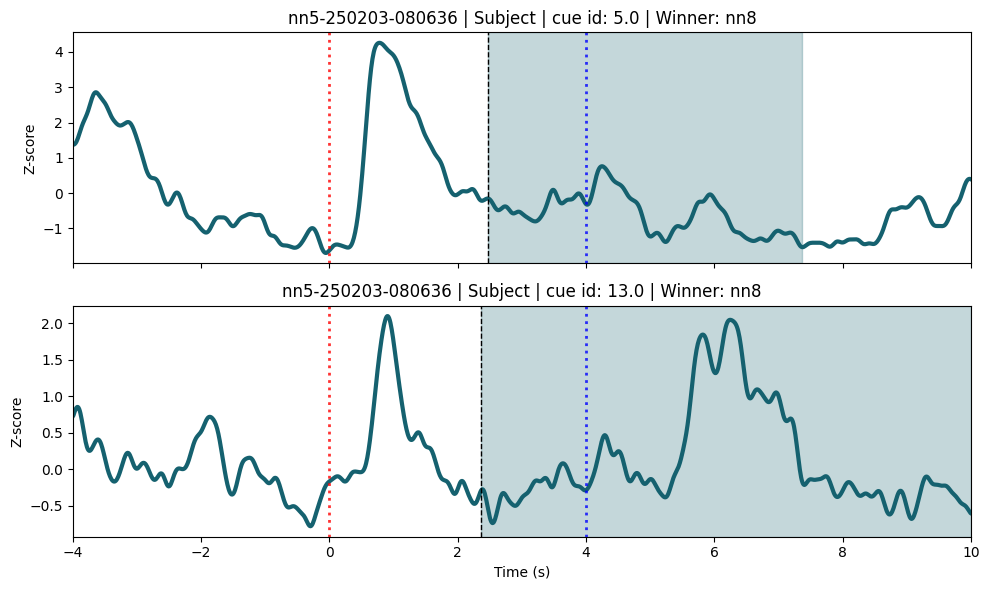

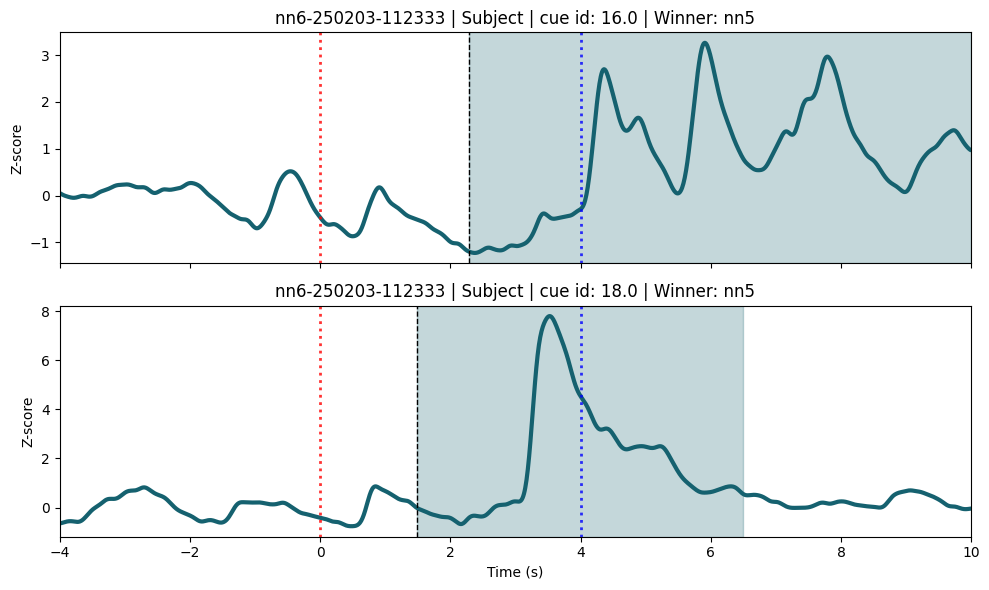

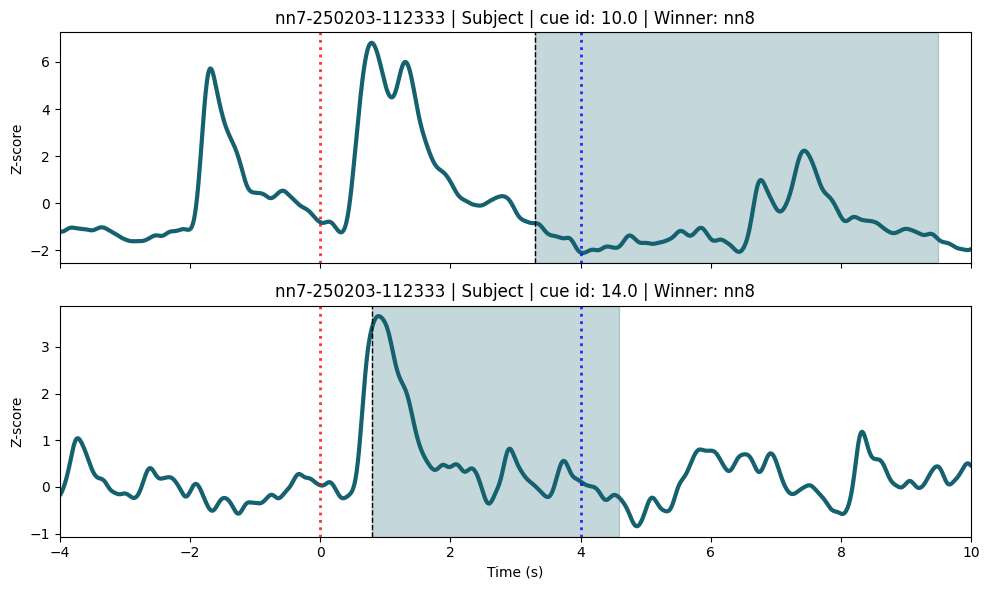

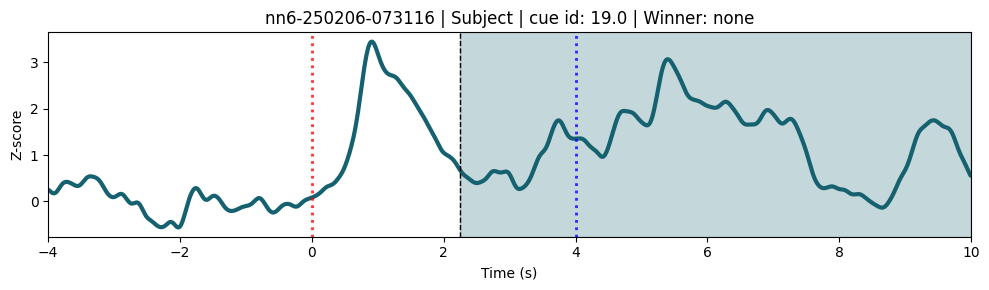

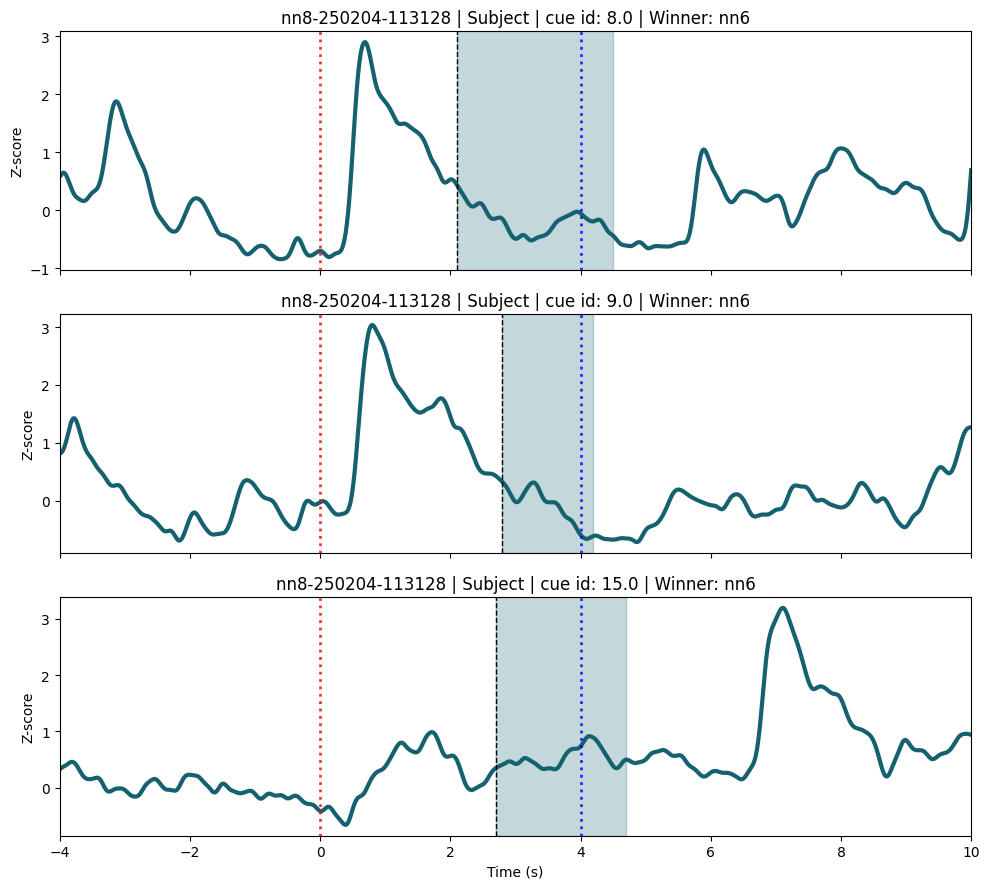

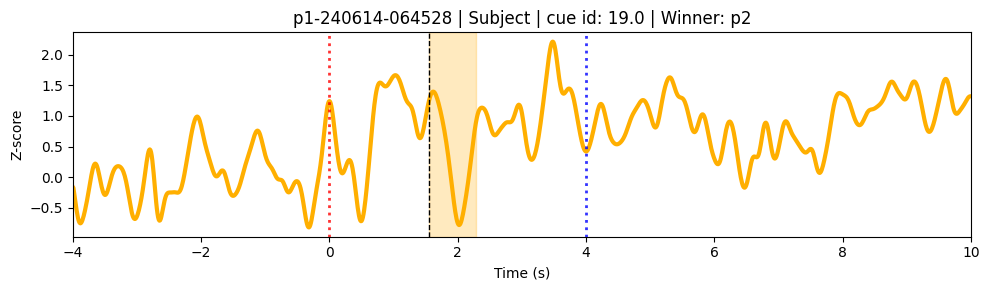

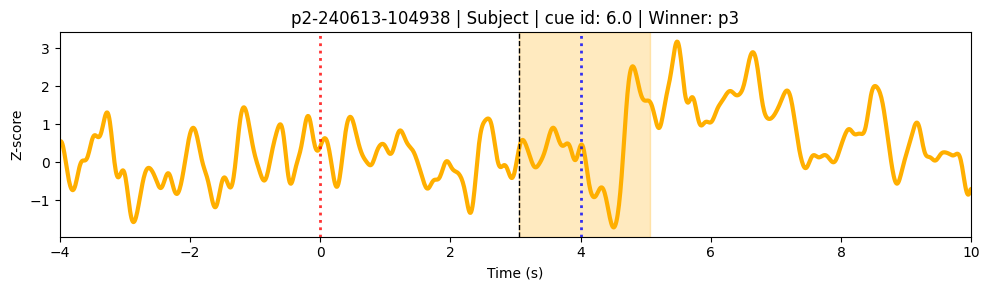

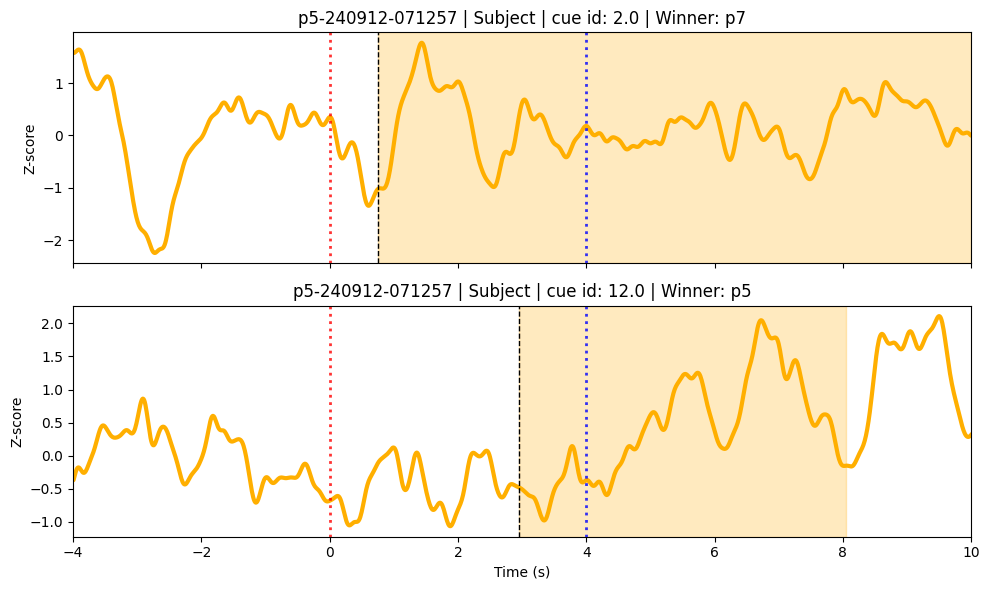

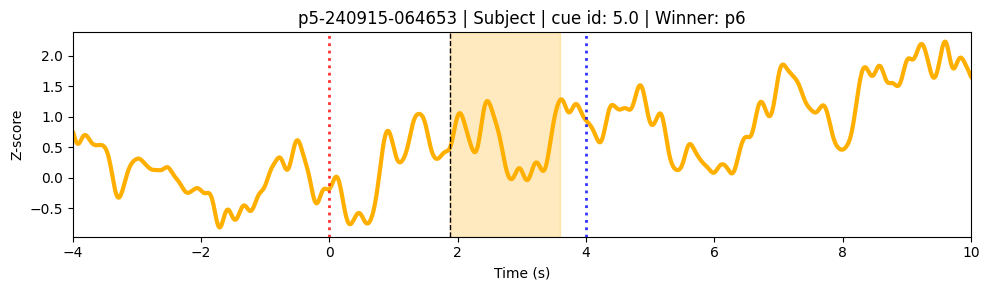

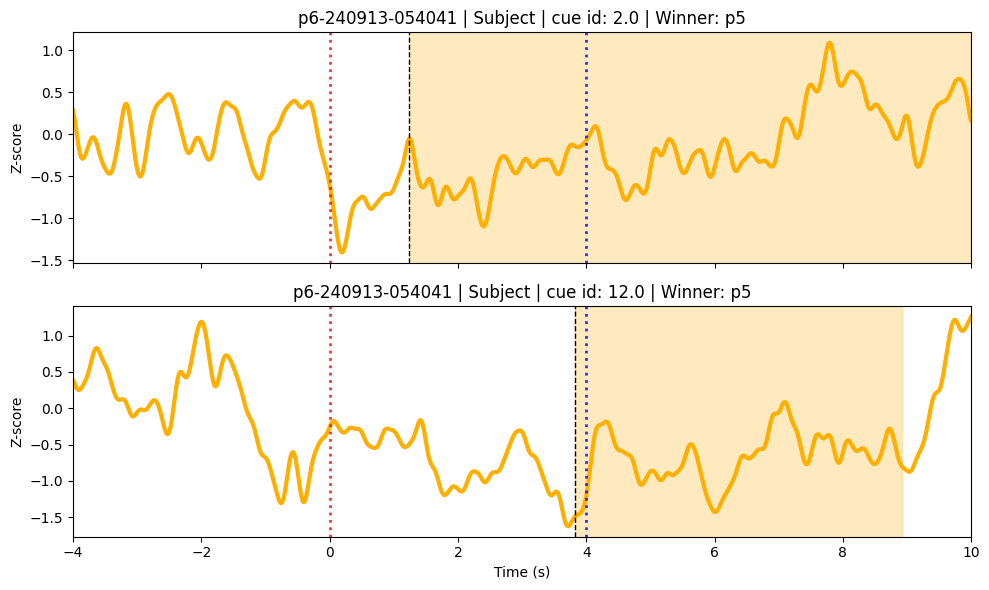

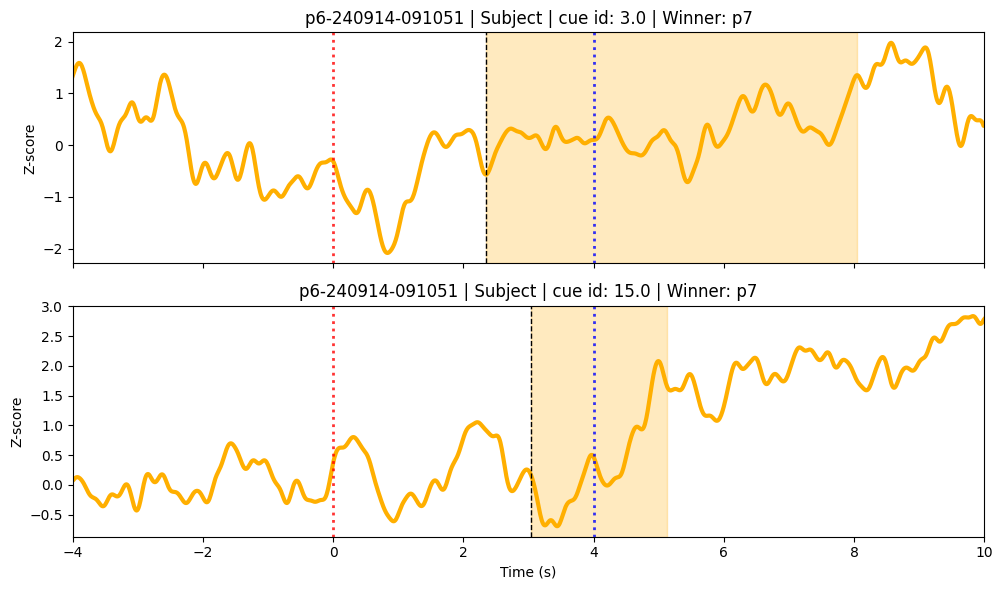

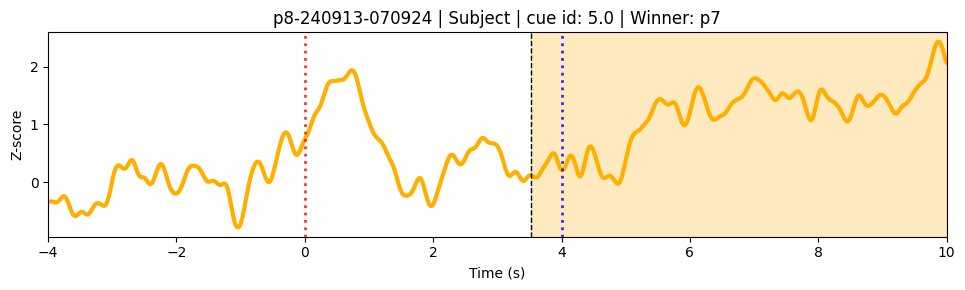

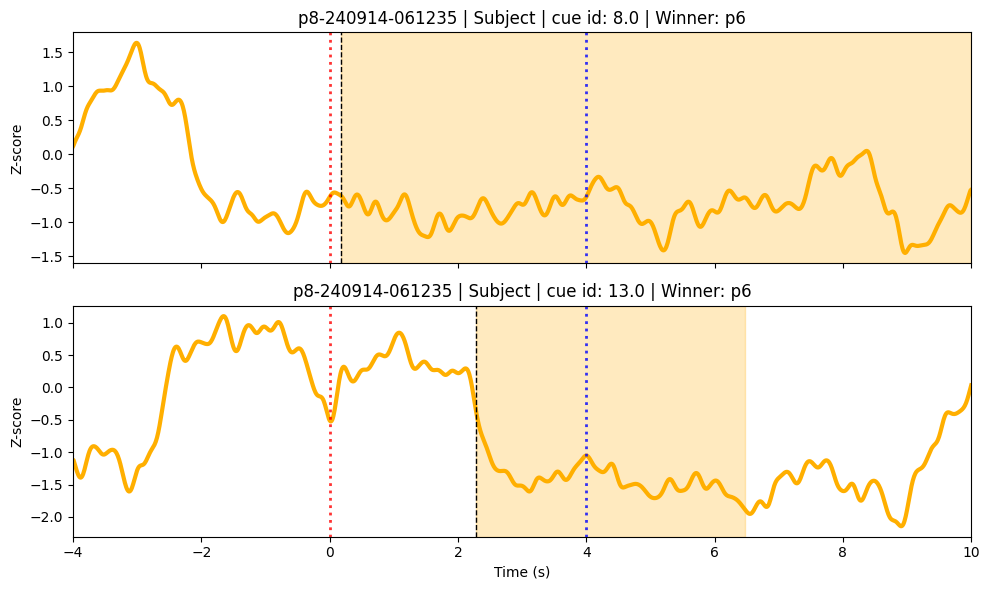

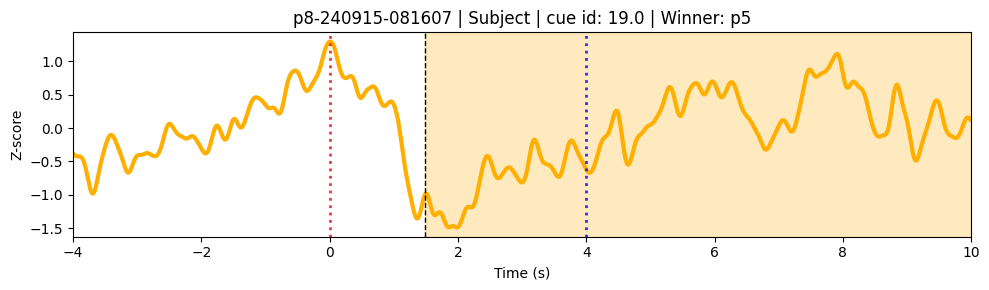

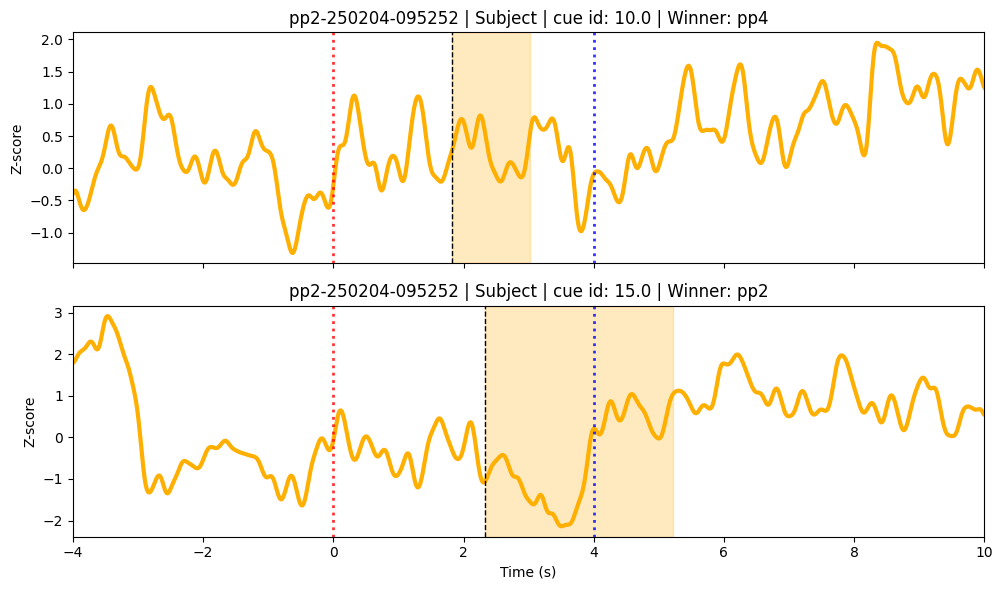

[SKIP] No valid bouts for pp2-250205-122507, initiator=Subject


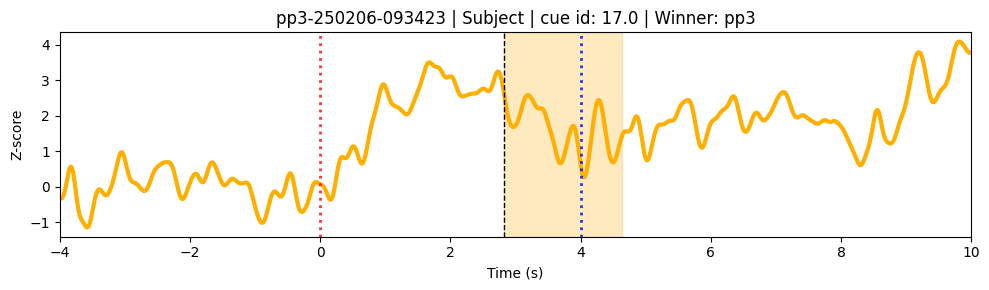

[SKIP] No valid bouts for pp7-250206-062728, initiator=Subject


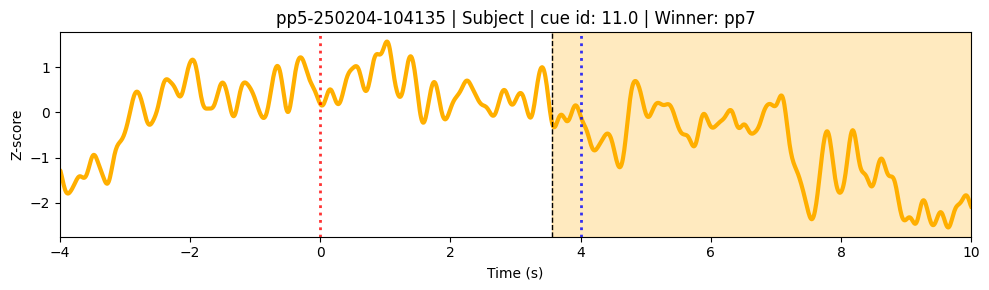

In [9]:
experiment.plot_event_bank_by_trial2(initiator="Subject",
                            figsize=(10, 5),
                            alpha=1,
                            window=(-4, 10))

[SKIP] No valid bouts for n5-240913-094304, initiator=Social Agent


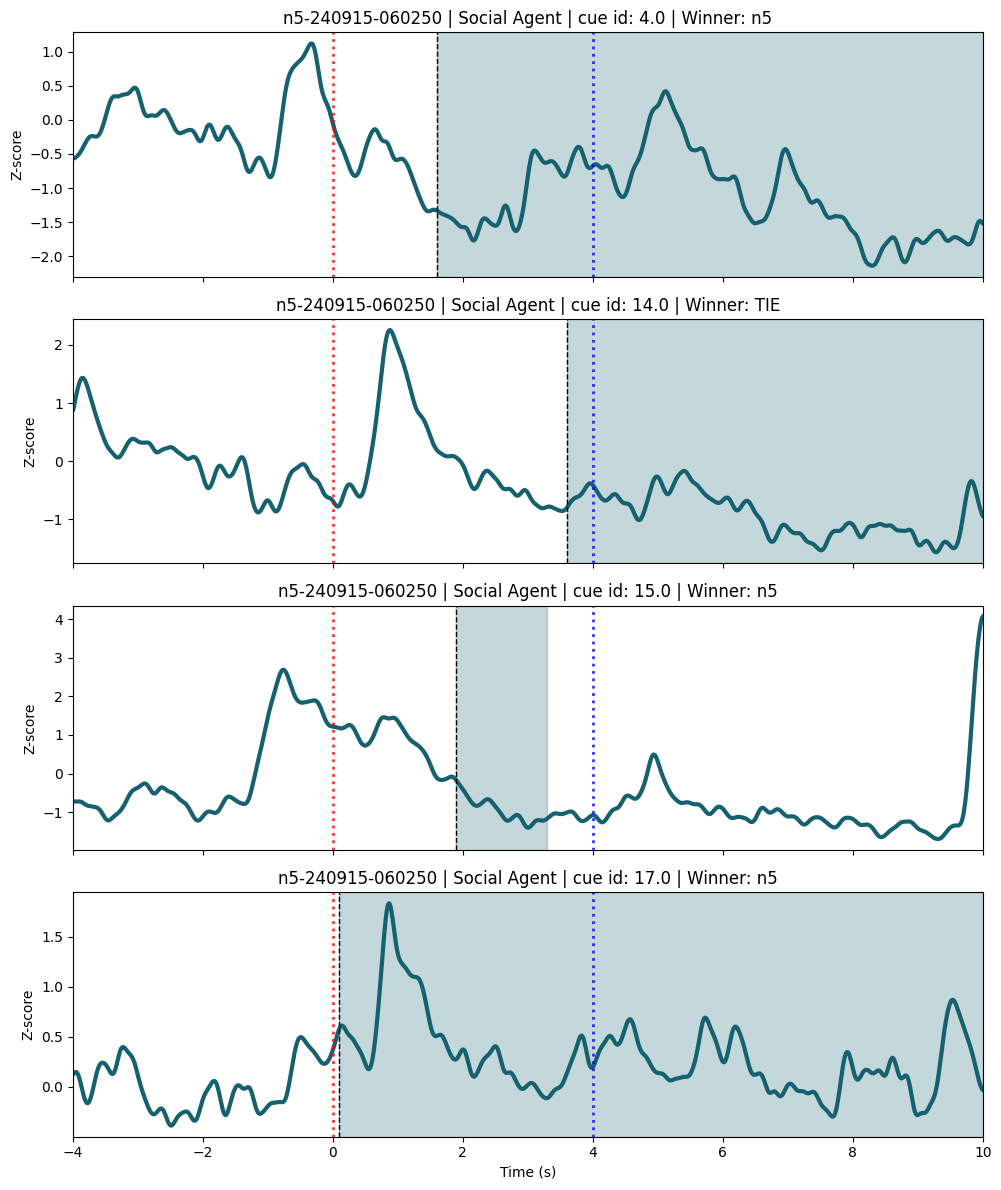

[SKIP] No valid bouts for n7-240912-095235, initiator=Social Agent
[SKIP] No valid bouts for n7-240914-082547, initiator=Social Agent


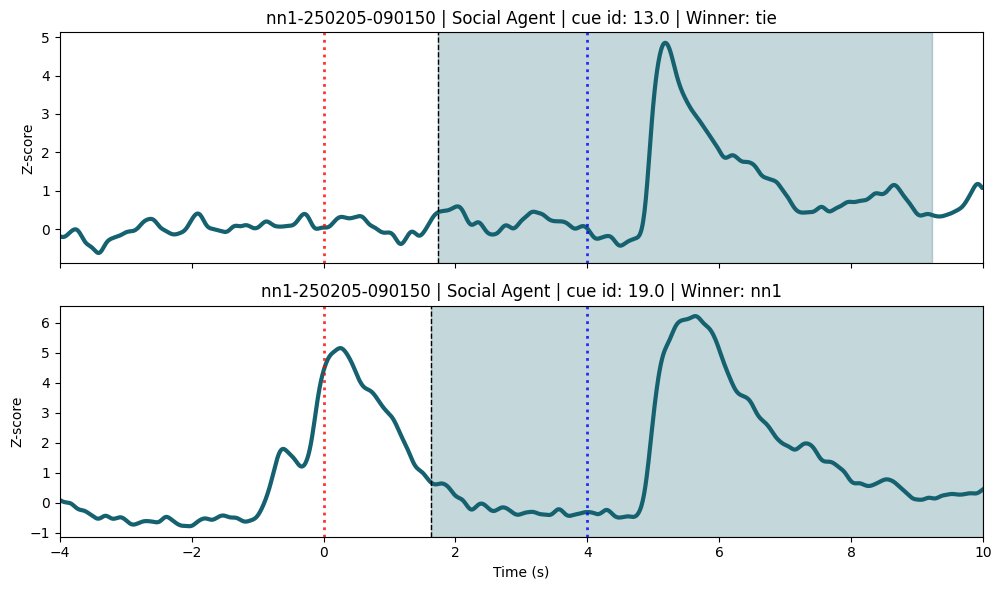

[SKIP] No valid bouts for pp3-250204-122327, initiator=Social Agent


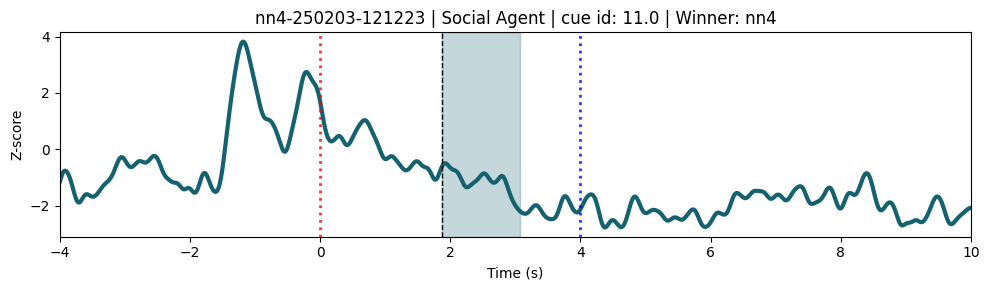

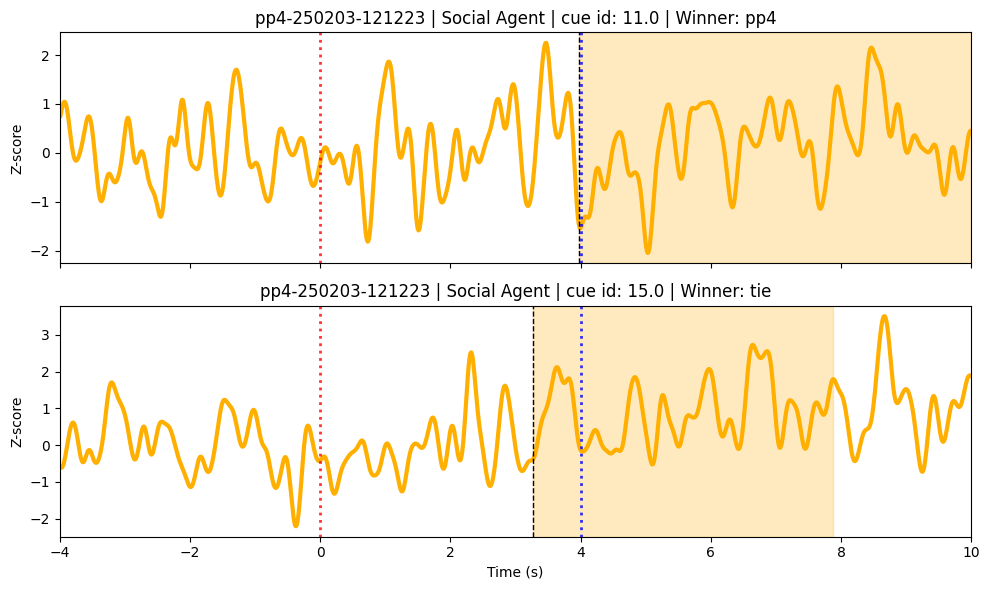

[SKIP] No valid bouts for nn5-250203-080636, initiator=Social Agent


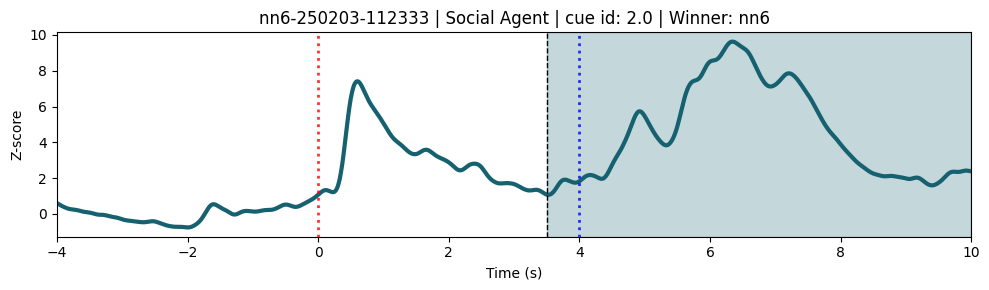

[SKIP] No valid bouts for nn7-250203-112333, initiator=Social Agent


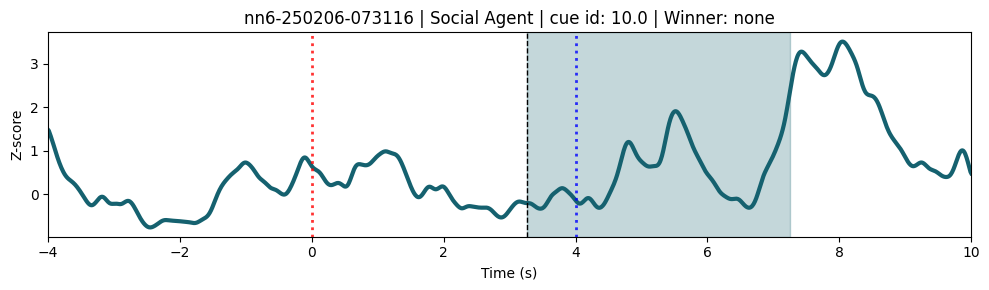

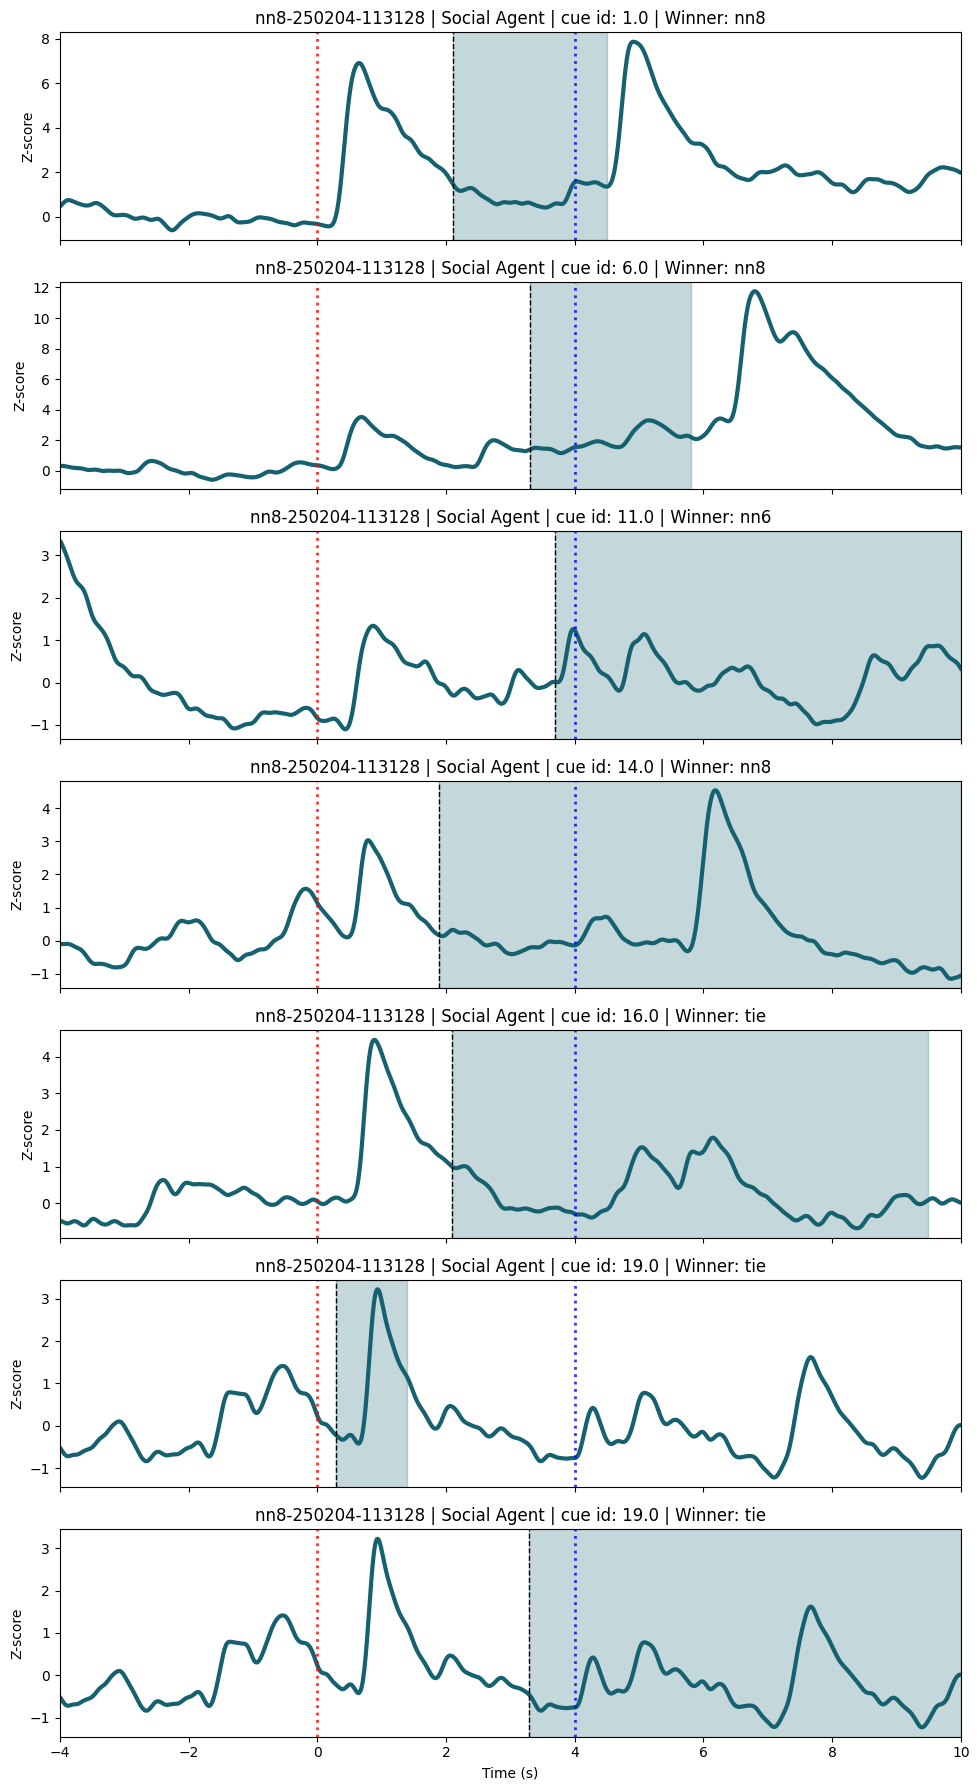

[SKIP] No valid bouts for p1-240614-064528, initiator=Social Agent


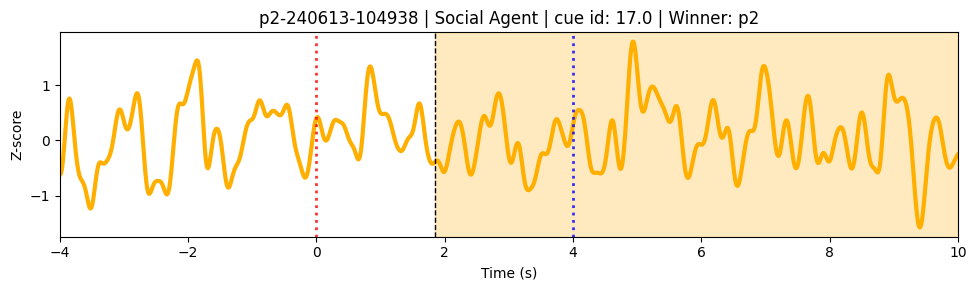

[SKIP] No valid bouts for p5-240912-071257, initiator=Social Agent


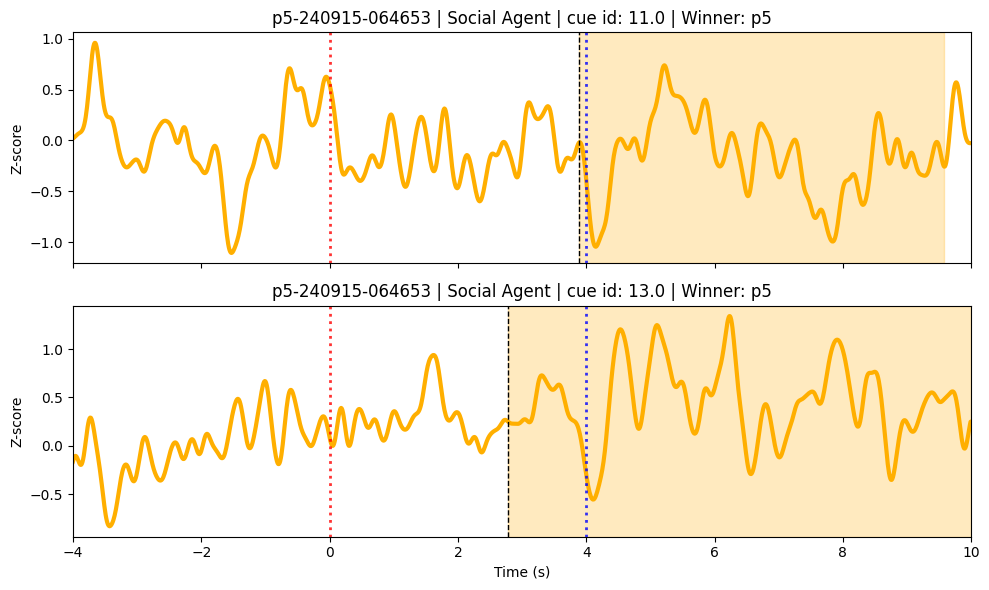

[SKIP] No valid bouts for p6-240913-054041, initiator=Social Agent
[SKIP] No valid bouts for p6-240914-091051, initiator=Social Agent
[SKIP] No valid bouts for p8-240913-070924, initiator=Social Agent
[SKIP] No valid bouts for p8-240914-061235, initiator=Social Agent


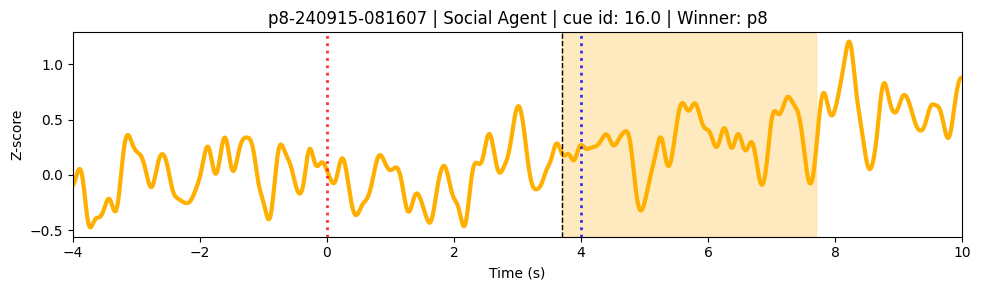

[SKIP] No valid bouts for pp2-250204-095252, initiator=Social Agent


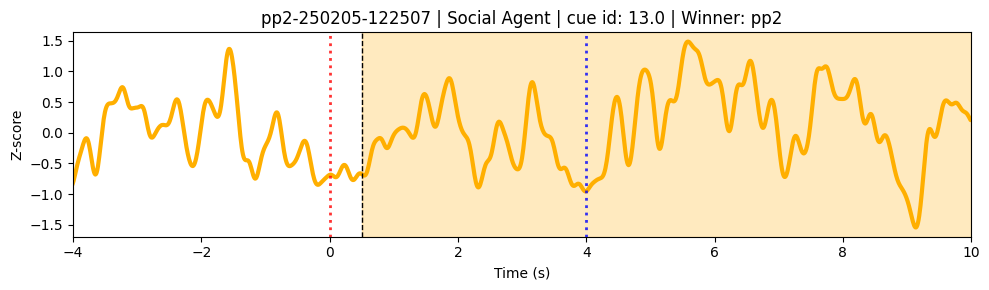

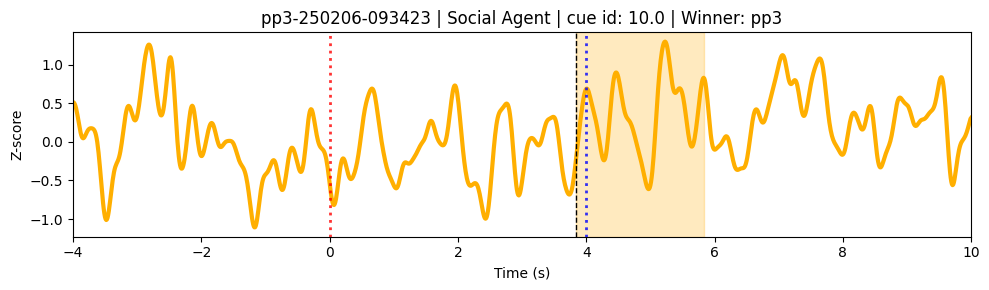

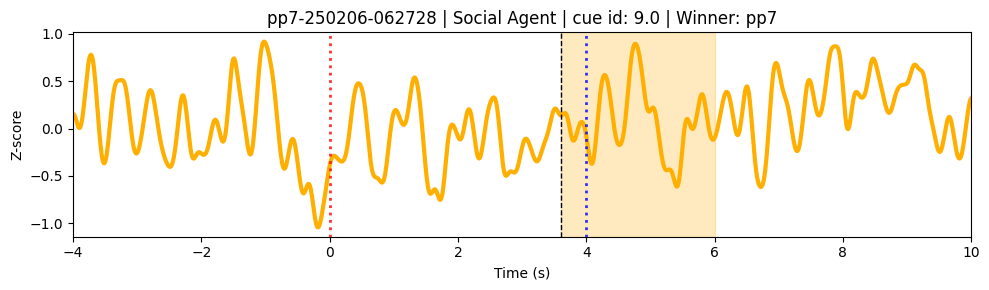

[SKIP] No valid bouts for pp5-250204-104135, initiator=Social Agent


In [10]:
experiment.plot_event_bank_by_trial2(initiator="Social Agent",
                            figsize=(10, 5),
                            alpha=1,
                            window=(-4, 10))

In [14]:
def plot_mean_traces(results, initiator=None, winner=None, color=nac, size=(8,5)):
    # -----------------------------
    # SAFETY CHECK (IMPORTANT)
    # -----------------------------
    if results is None:
        print(f"[SKIP] No data for initiator={initiator}, winner={winner}")
        return

    if "time" not in results:
        print("[SKIP] malformed results dict")
        return

    t = results["time"]
    mean = results["mean"]
    sem = results["sem"]

    # extra safety
    if len(t) == 0 or len(mean) == 0:
        print("[SKIP] empty traces")
        return
    plt.figure(figsize=size)
    plt.plot(t, mean, color=color)

    plt.fill_between(
        t,
        mean - sem,
        mean + sem,
        color=color,
        alpha=0.3
    )
    plt.axvline(0, color='k', ls='--', lw=2)
    plt.axvline(4, color='#FF69B4', ls='-', lw=2)
    plt.xlabel('Time from Cue (s)')
    plt.ylabel('Z-scored ΔF/F')
    plt.title(f'PSTH {initiator} initiated {winner} win')
    plt.tight_layout()
    plt.show

In [12]:
# 2) compute each subject’s mean trace for “Tone” events:
subj_initiate_win_n = experiment.compute_subject_mean_traces_tone_initiator(initiator="Subject",
                                                                            winner="Subject",
                                                                            window=(-4, 10),
                                                                            region="nac")

subj_initiate_lose_n = experiment.compute_subject_mean_traces_tone_initiator(initiator="Subject",
                                                                           winner="Social Agent",
                                                                           window=(-4, 10),
                                                                           region="nac")

agent_initiate_win_n = experiment.compute_subject_mean_traces_tone_initiator(initiator="Social Agent",
                                                                           winner="Social Agent",
                                                                           window=(-4, 10),
                                                                           region="nac")

agent_initiate_lose_n = experiment.compute_subject_mean_traces_tone_initiator(initiator="Social Agent",
                                                                            winner="Subject",
                                                                            window=(-4, 10),
                                                                            region="nac")

subj_initiate_win_p = experiment.compute_subject_mean_traces_tone_initiator(initiator="Subject",
                                                                            winner="Subject",
                                                                            window=(-4, 10),
                                                                            region="pfc")

subj_initiate_lose_p = experiment.compute_subject_mean_traces_tone_initiator(initiator="Subject",
                                                                           winner="Social Agent",
                                                                           window=(-4, 10),
                                                                           region="pfc")

agent_initiate_win_p = experiment.compute_subject_mean_traces_tone_initiator(initiator="Social Agent",
                                                                           winner="Social Agent",
                                                                           window=(-4, 10),
                                                                           region="pfc")

agent_initiate_lose_p = experiment.compute_subject_mean_traces_tone_initiator(initiator="Social Agent",
                                                                            winner="Subject",
                                                                            window=(-4, 10),
                                                                            region="pfc")

No traces matched filters
No traces matched filters


[SKIP] No data for initiator=subject, winner=subject


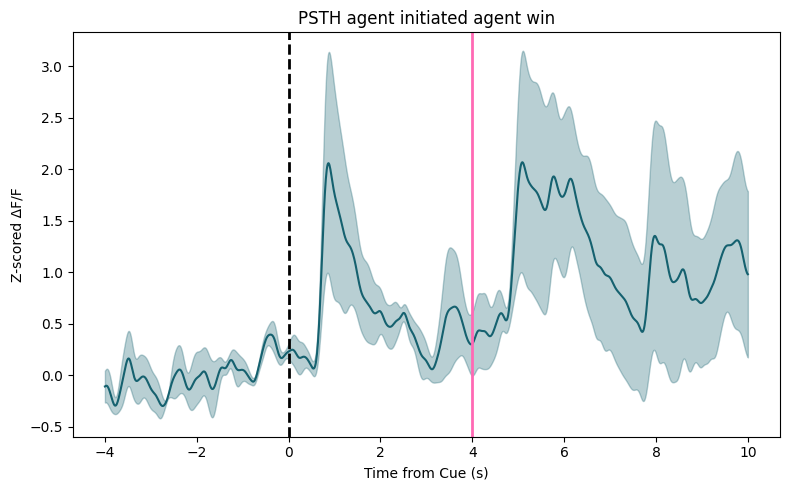

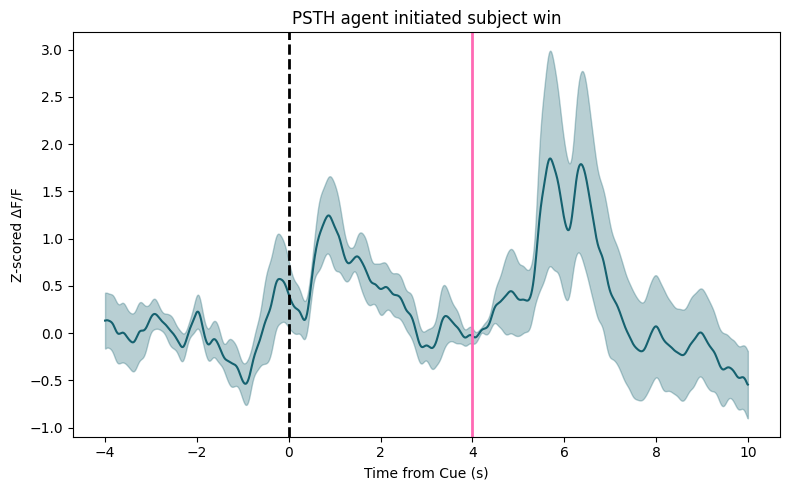

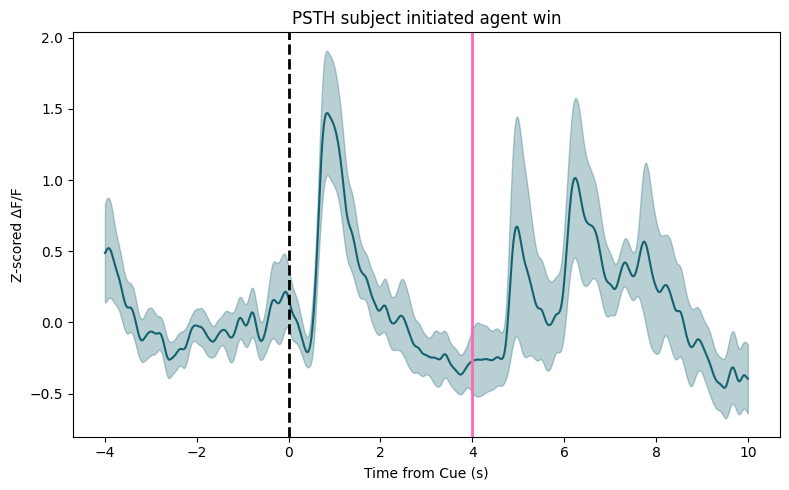

In [15]:
plot_mean_traces(agent_initiate_win_n, initiator="agent", winner="agent", color=nac)
plot_mean_traces(agent_initiate_lose_n, initiator="agent", winner="subject", color=nac)
plot_mean_traces(subj_initiate_win_n, initiator="subject", winner="subject", color=nac)
plot_mean_traces(subj_initiate_lose_n, initiator="subject", winner="agent", color=nac)

[SKIP] No data for initiator=agent, winner=agent


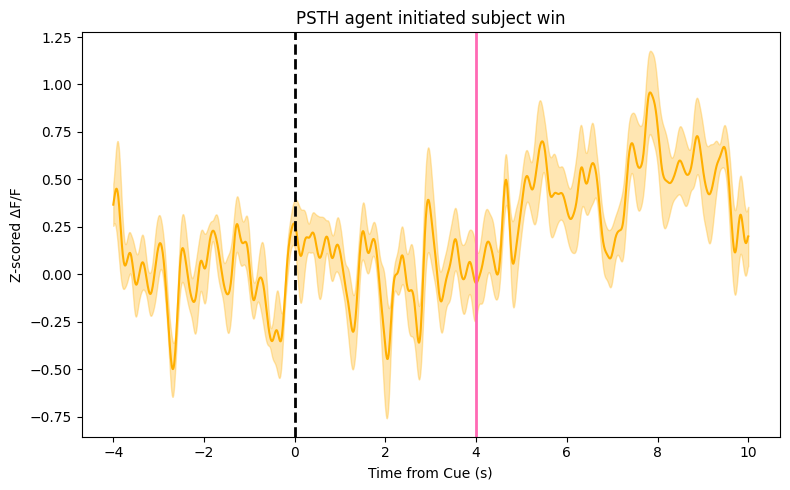

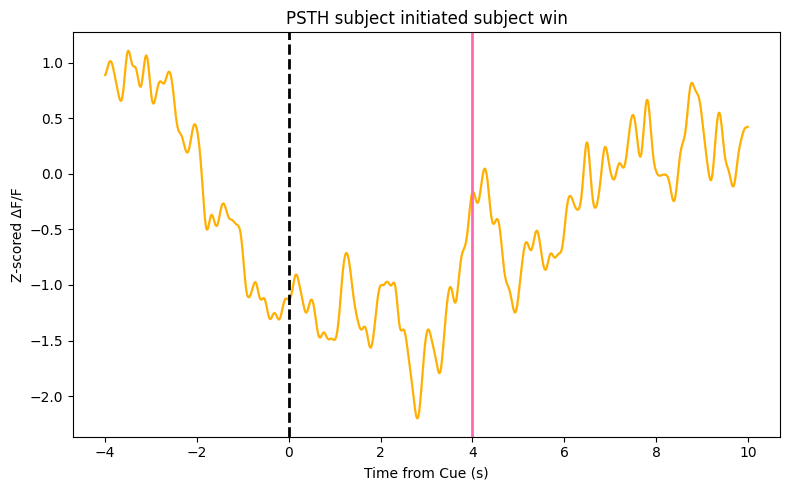

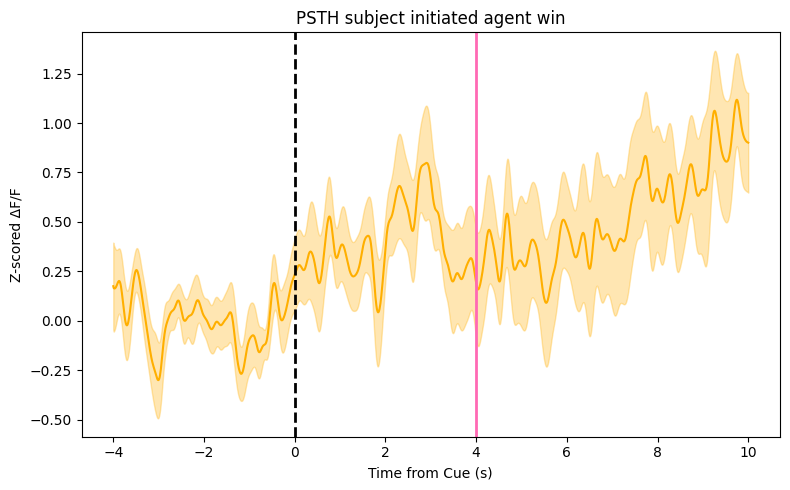

In [16]:
plot_mean_traces(agent_initiate_win_p, initiator="agent", winner="agent", color=mpfc)
plot_mean_traces(agent_initiate_lose_p, initiator="agent", winner="subject", color=mpfc)
plot_mean_traces(subj_initiate_win_p, initiator="subject", winner="subject", color=mpfc)
plot_mean_traces(subj_initiate_lose_p, initiator="subject", winner="agent", color=mpfc)

In [ ]:
def count_bouts_by_region_and_initiator(experiment):

    rows = []

    for trial_name, trial in experiment.trials.items():

        # skip invalid trials
        if trial.behaviors is None or trial.behaviors.empty:
            continue

        df = trial.behaviors

        # infer region per file ONLY as fallback
        # (DO NOT rely on this for per-event truth)
        if isinstance(trial.subject_name, str) and "_" in trial.subject_name:
            parts = trial.subject_name.split("_")
        else:
            parts = [trial.subject_name]

        # -------------------------
        # SUBJECT-INITIATED BOUTS
        # -------------------------
        subj_df = df[
            (df["Bout"] == "subject_behavior") &
            (df["Initiators"] == "Subject")
        ]

        if not subj_df.empty:
            rows.append({
                "region_file": parts[0][0],   # fallback only
                "initiator": "Subject",
                "count": len(subj_df)
            })

        # -------------------------
        # AGENT-INITIATED BOUTS
        # -------------------------
        agent_df = df[
            (df["Bout"] == "agent_behavior") &
            (df["Initiators"] == "Social Agent")
        ]

        if not agent_df.empty:
            rows.append({
                "region_file": parts[0][0],   # fallback only
                "initiator": "Social Agent",
                "count": len(agent_df)
            })

    # -------------------------
    # BUILD OUTPUT TABLES
    # -------------------------
    df_counts = pd.DataFrame(rows)

    if df_counts.empty:
        return df_counts, df_counts, df_counts

    summary = (
        df_counts
        .groupby(["region_file", "initiator"])["count"]
        .sum()
        .reset_index()
    )

    pivot = summary.pivot(
        index="region_file",
        columns="initiator",
        values="count"
    ).fillna(0)

    return df_counts, summary, pivot

In [ ]:
df_counts, summary, pivot = count_bouts_by_region_and_initiator(experiment)

print(summary)
print(pivot)

  region_file     initiator  count
0           n  Social Agent     18
1           n       Subject     17
2           p  Social Agent      7
3           p       Subject     17
initiator    Social Agent  Subject
region_file                       
n                      18       17
p                       7       17
